In [1]:
using DelimitedFiles
using CairoMakie

In [2]:
hw = 1024
chip_hw = 0.016

0.016

In [3]:
power = reshape(readdlm("../data/power_1024", '\t', Float32)[:,1], (hw, hw))
temp = reshape(readdlm("../out", '\t', Float32)[:,2], (hw, hw))

1024×1024 Matrix{Float32}:
 323.83   323.83   323.83   323.83   …  322.95   322.95   322.949  322.949
 323.83   323.83   323.83   323.83      322.95   322.95   322.949  322.949
 323.83   323.83   323.83   323.83      322.95   322.95   322.949  322.949
 323.831  323.831  323.831  323.831     322.95   322.95   322.949  322.949
 323.832  323.832  323.831  323.831     322.95   322.95   322.949  322.949
 323.832  323.832  323.832  323.832  …  322.95   322.95   322.95   322.949
 323.833  323.833  323.833  323.833     322.95   322.95   322.95   322.95
 323.835  323.835  323.835  323.834     322.95   322.95   322.95   322.95
 323.836  323.836  323.836  323.836     322.95   322.95   322.95   322.95
 323.837  323.837  323.837  323.837     322.95   322.95   322.95   322.95
   ⋮                                 ⋱    ⋮                        
 323.989  323.989  323.989  323.989  …  323.015  323.014  323.014  323.014
 323.987  323.987  323.987  323.987     323.015  323.014  323.014  323.014
 323.986 

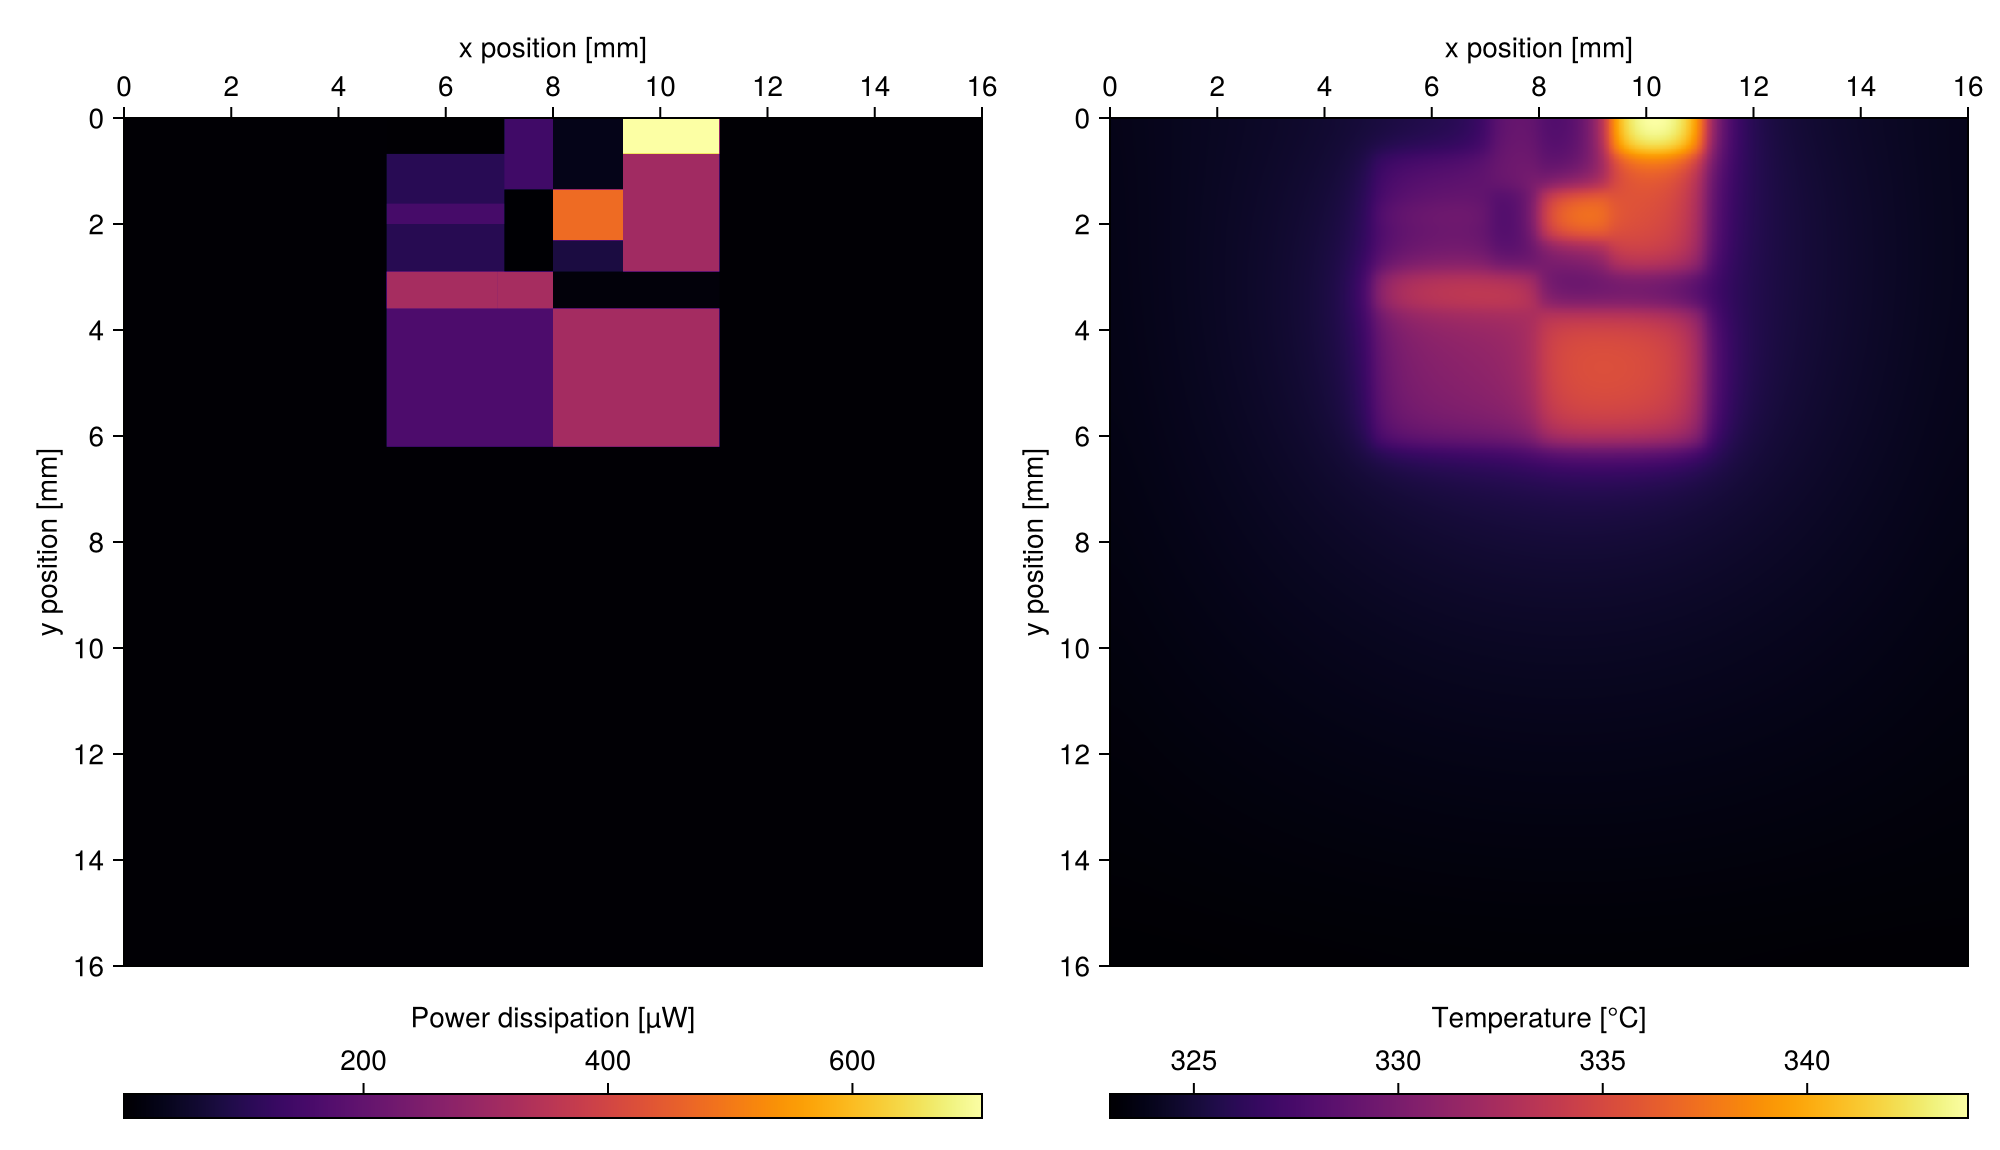

In [4]:
fig = Figure(size=(1000, 575))
power_ax = Axis(fig[1,1], xlabel="x position [mm]", ylabel="y position [mm]", yreversed=true, xaxisposition=:top)
temp_ax = Axis(fig[1,2], xlabel="x position [mm]", ylabel="y position [mm]", yreversed=true, xaxisposition=:top)
size_range = (0:hw) .* (chip_hw / hw) .* 1e3
power_hm = heatmap!(power_ax, size_range, size_range, power .* 1e6, colormap=:inferno, label="Power dissipation [W]")
temp_hm = heatmap!(temp_ax, size_range, size_range, temp, colormap=:inferno, label="Temperature [°C]")
Colorbar(fig[2,1], power_hm, vertical=false, label="Power dissipation [µW]")
Colorbar(fig[2,2], temp_hm, vertical=false, label="Temperature [°C]")
save("heat.png", fig)
fig